# **Data from the Bones: What the Fossil Record Tells Us About Dinosaurs**

Dinosaurs are household names, but our understanding of them is often stuck in movie scenes. Where did they actually live? How long did their lineages survive? Did some have evolutionary advantages?

In this notebook, we perform a comprehensive analysis of the paleobiological dataset focusing on the Dinosauria taxons. The analysis aims to uncover patterns, trends, and insights regarding the diversity, distribution, and evolutionary history of these ancient species.

***Geographical Analysis***: Using the coordinates of fossil findings, we map the geographical spread of species, revealing hotspots of paleobiological activity and potential correlations with ancient environmental conditions.

***Species Distribution***: We analyze the distribution of species across different taxonomic orders, periods, and geographical locations. Visualizations such as bar charts, pie charts, and maps are employed to highlight diversity and prevalence within these groups.

- **Analyze Basal Species for orders, superorders, and infraorders (look at max MYA)**
- **Analyze Genus, Order, and Fossil Occ Distribution**
- **etc.**

***Temporal Analysis***: By examining the first and last appearances of species, we create timelines to track the evolutionary lifespan and extinction patterns. This helps to identify periods of significant biodiversity or extinction events.

***Lifespan Analysis***: The analysis of species lifespans across different orders and periods provides insights into the survival and adaptation strategies of these taxa. Statistical comparisons and visual summaries are used to present the findings.

***TBD:*** ...

In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import sqlite3
import geopandas as gpd

# Change the path to your database file as needed
conn = sqlite3.connect('/paleo.database')


- Where were the most population dense locations?
  - Did climate affect this? (Explore Laurasia/Gondwana and Pangea)
- What were the longest existing genera?
  - What other factors may have contributed towards longevity?
  - Was it physical location, temporal location, or diet?
  - How (if it even did) did the climate or environment affect the fauna during specific ages within the Mesozoic?
	  - Were there signs that back up these claims?
- How fast was the evolution from Therapod to Avian? 
  - Was there a clear shift prior to the K-Pg Extinction event?
  - How did Avian descendants compare to the rest of the genera within Dinosauria
  
Questions from GPT
-	**Species Discovery Over Time:** Are we seeing more recent discoveries of specific clades? (good historical insight)
-	**Taxonomic Gaps:** Plot genus vs. species ratios — some orders may be poorly studied.
-	**Formation Focus:** What makes formations like Hell Creek so fossil-rich? Could be a feature in your app.

In [139]:
occ = pd.read_sql_query("select * from dino_occurrences", conn)
occ.drop(columns=['index'], inplace=True)

occ_spec = pd.read_sql_query("select * from dino_occurrences left join dino_species on dino_occurrences.Fossil=dino_species.Species", conn)
occ_spec.drop(columns=['index', 'Species'], inplace=True)
occ_spec.head()


,Fossil,Longitude,Latitude,Formation,Country,State,County,Collection,GeoComments,PaleoLongitude,...,PaleoModel,Genus,Diet,MaxMYA,MinMYA,EarlyAge,LateAge,EarlyPeriod,LatePeriod,LifespanMYA
0,Chaoyangsaurus youngi,123.966698,42.933300,Tuchengzi,CN,Liaoning,Chaoyang,10755,"Chaoyang area of Liaoning Province, NE China",127.48,...,gplates,Chaoyangsaurus,Herbivore,152.21,132.60,Kimmeridgian,Valanginian,Jurassic,Cretaceous,19.61
1,Protarchaeopteryx robusta,120.733330,41.799999,Yixian,CN,Liaoning,None,10764,Sihetun area near Beipiao city,129.23,...,gplates,Protarchaeopteryx,Omnivore,125.77,119.57,Barremian,Aptian,Cretaceous,Cretaceous,6.20
2,Caudipteryx zoui,120.733330,41.799999,Yixian,CN,Liaoning,None,10764,Sihetun area near Beipiao city,129.23,...,gplates,Caudipteryx,Omnivore,125.77,119.57,Barremian,Aptian,Cretaceous,Cretaceous,6.20
3,Gorgosaurus libratus,-111.528732,50.740726,Dinosaur Park,CA,Alberta,None,11890,"near Steveville, Alberta (now Dinosaur Provinc...",-65.72,...,gplates,Gorgosaurus,Carnivore,83.60,72.20,Campanian,Campanian,Cretaceous,Cretaceous,11.40
4,Gorgosaurus libratus,-111.549347,50.737015,Dinosaur Park,CA,Alberta,None,11893,"near Steveville, Alberta (now Dinosaur Provinc...",-65.75,...,gplates,Gorgosaurus,Carnivore,83.60,72.20,Campanian,Campanian,Cretaceous,Cretaceous,11.40


## **Geographical Analysis**

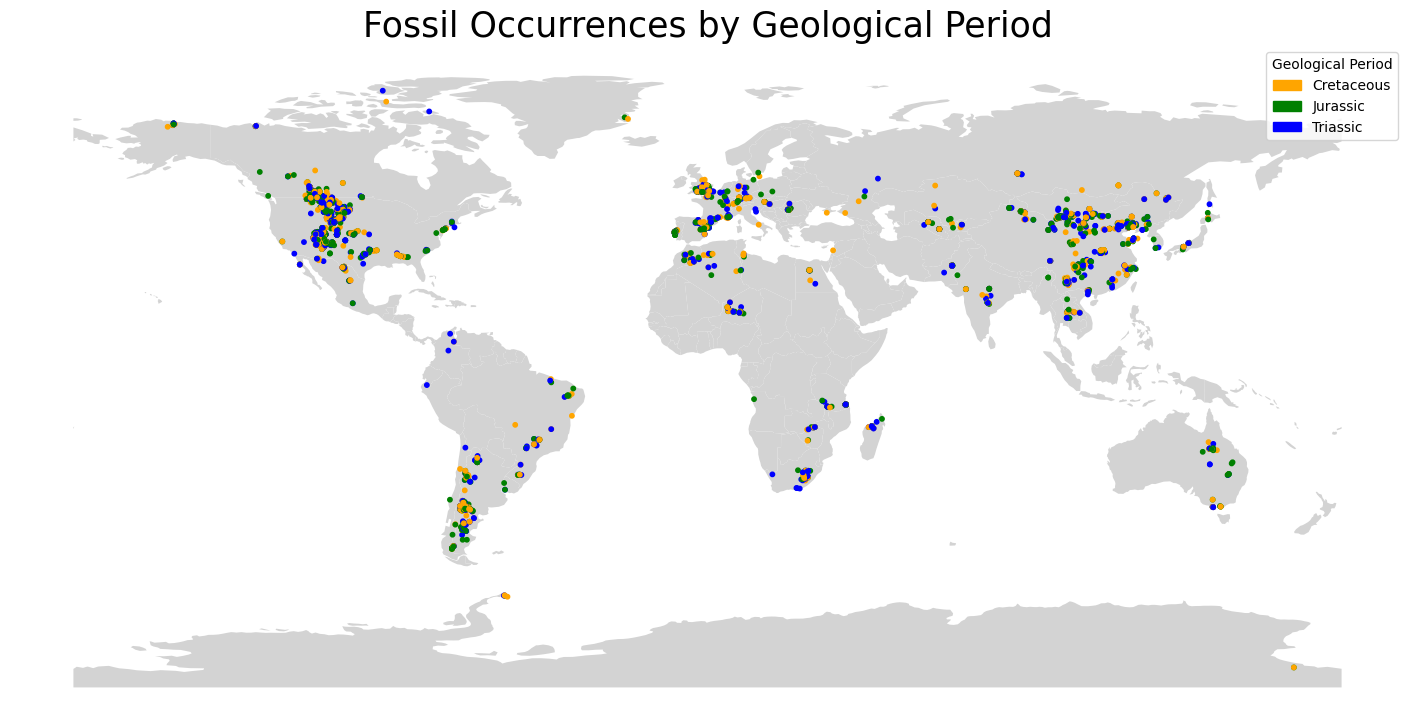

In [162]:
geo_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(geo_url)
fossil_plot = gpd.GeoDataFrame(occ, geometry=gpd.points_from_xy(occ['Longitude'], occ['Latitude']))

fig, ax = plt.subplots(figsize=(18, 9))
world.plot(ax=ax, color="lightgrey")

colors = {'Cretaceous': 'orange',
          'Jurassic': 'green',
          'Triassic': 'blue',}
cmap = mpl.colors.ListedColormap([colors[e] for e in occ_spec['EarlyPeriod'].unique()])

fossil_plot.plot(ax=ax, markersize=10, alpha=1, cmap=cmap, legend=True)
handles = [mpatches.Patch(color=color, label=period) for period, color in colors.items()]
ax.legend(handles=handles, title='Geological Period')

_ = ax.axis("off")

ax.set_title("Fossil Occurrences by Geological Period", fontsize=25)
plt.show()


From the above plot, we can see that a majority of Dinosaurs were found in the North American and East Asian Continents.

## **Lifespan Analysis**
- What were the longest existing genera?
  - What other factors may have contributed towards longevity?
  - Was it physical location, temporal location, or diet?
  - How (if it even did) did the climate or environment affect the fauna during specific ages within the Mesozoic?
	  - Were there signs that back up these claims?


**Author**: Vernon Edejer  
**Date**: May-2025  
**Data Source**: `paleo.db` (SQLite)  
**Description**: This notebook performs EDA on a dataset composed of genera, species, and fossil occurrence data from the Mesozoic time period, sourced from PaleoDB and Wikipedia.